# Deep learning for time series: RNN, GRU & LSTM

This notebook is part of a practical time-series series. Earlier parts covered classical tools — smoothing, ARMA/ARIMA, hierarchical reconciliation, survival analysis. Here we cross over into **deep learning**: the family of *recurrent* neural networks that were, for years, the default way to put a neural net on a sequence.

We will climb a deliberate ladder, adding exactly one idea at each rung:

1. a single **SimpleRNN** layer predicting one step ahead — the smallest thing that works;
2. a **stacked** RNN — more depth;
3. a **multi-step** RNN — a longer forecast horizon, which exposes the *vanishing-gradient* problem;
4. a **GRU** — gating, the first cure for that problem;
5. an **LSTM** — a second, more elaborate cure with an explicit memory cell;
6. a **bidirectional LSTM with covariates** — the fully general setup (multivariate input, two reading directions).

We deliberately stop before **transformers** and the attention mechanism — those get their own treatment later. The closing cell explains exactly where this notebook hands off to them.

The reader is assumed comfortable with Python but new to recurrent networks, so library mechanics are explained as they appear.

# Setup

In [1]:
# Standard library imports
import os
import warnings

# Third-party imports — data handling
import numpy as np
import pandas as pd

# Third-party imports — deep learning (TensorFlow / Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, SimpleRNN, GRU, LSTM, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

# Third-party imports — preprocessing & metrics
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Third-party imports — visualization
import matplotlib.pyplot as plt

# Configuration & settings
warnings.simplefilter(action='ignore', category=FutureWarning)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'    # quieten TensorFlow's start-up chatter

I0000 00:00:1781471671.341676     532 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781471687.929210     532 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1781471697.425037     532 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


The import block is grouped on purpose, standard library first and third-party packages after, sorted from data handling through modeling to plotting, so the dependency story reads top to bottom.

The `import numpy as np` and `import pandas as pd` lines pull in the two foundations of the scientific-Python stack and give them short aliases — `np` for numerical arrays, `pd` for tabular data — so every later `np.` or `pd.` is a call into those libraries. **NumPy** arrays are the currency a neural network actually consumes; **pandas** is how we load and shape the raw series before handing it over.

The TensorFlow block is the new material. **`tensorflow`** (aliased `tf`) is the deep-learning engine; **`Sequential`** is the simplest way to define a model — a straight stack of layers where each feeds the next. From `tensorflow.keras.layers` we import the layer types this notebook studies: **`SimpleRNN`**, **`GRU`** and **`LSTM`** are the three recurrent cells, **`Dense`** is an ordinary fully-connected output layer, **`Input`** declares the shape of incoming data, and **`Bidirectional`** is a wrapper we save for the final section. **`EarlyStopping`** is a callback that halts training once validation performance stops improving.

From scikit-learn we take **`MinMaxScaler`** (rescales values into a fixed range — neural nets train far better on small, bounded inputs) and two error functions, `mean_squared_error` and `mean_absolute_error`, that we will wrap into a tidy metrics helper.

Finally the configuration lines: `warnings.simplefilter` suppresses the deprecation noise that clutters TensorFlow output, and the `TF_CPP_MIN_LOG_LEVEL` environment variable silences the low-level C++ logging so the cell outputs stay readable.

In [2]:
# general settings
class CFG:
    data_folder = './data/'
    graph_folder = './graphs/'
    img_dim1 = 16
    img_dim2 = 6
    SEED = 42
    LOOK_BACK = 30      # length of the input window (history fed to the network)
    LOOK_AHEAD = 1      # forecast horizon for the benchmark task (steps predicted at once)
    UNITS = 24          # hidden units per recurrent layer
    EPOCHS = 20         # max passes over the training set (early stopping can cut this short)
    BATCH_SIZE = 32
    CUTOFF = 3000       # chronological train/validation boundary (index into the windows)

# display style
plt.style.use("seaborn-v0_8")
plt.rcParams["figure.figsize"] = (CFG.img_dim1, CFG.img_dim2)

# reproducibility: fix every random-number generator the pipeline touches
np.random.seed(CFG.SEED)
tf.random.set_seed(CFG.SEED)

Every notebook in this series opens with a single **`CFG`** class that parks all the tunable constants in one place. Reaching for `CFG.LOOK_BACK` later is self-documenting and means a change to the window length or the random seed happens in exactly one spot rather than scattered through the body.

The fields worth flagging: `LOOK_BACK = 30` is how many past days the network sees before making a prediction; `LOOK_AHEAD = 1` is how far ahead it forecasts on our main benchmark task (one day); `UNITS = 24` is the width of each recurrent layer; `EPOCHS = 20` caps how many times training sweeps the data; and `CUTOFF = 3000` is where we slice train from validation. Defining these as named constants is the notebook's standing rule against magic numbers buried inline.

`plt.style.use("seaborn-v0_8")` selects a clean default look for every plot, and the `figure.figsize` line makes figures wide enough to read a multi-year series.

The last two lines are about **reproducibility**. A neural network starts from randomly initialised weights and shuffles batches randomly, so two runs will differ unless we pin the randomness. `np.random.seed(CFG.SEED)` fixes NumPy's generator and `tf.random.set_seed(CFG.SEED)` fixes TensorFlow's. The value 42 is arbitrary — what matters is that it is *fixed*, so re-running the notebook reproduces the same numbers.

# Utils

Before any modeling we define a handful of small reusable helpers. The guiding principle for the whole series: anything we would otherwise type more than twice in the body becomes a function *here*, with sensible defaults, so the modeling cells below read as short declarative calls rather than walls of boilerplate.

In [3]:
def forecast_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {'MAE': float(np.round(mae, 4)), 'RMSE': float(np.round(rmse, 4))}

`forecast_metrics` is the scoring helper every model below will call. It takes the true values and the predictions and returns a small dictionary with two numbers. **MAE** (mean absolute error) is the average size of the miss in the original units — here, degrees Celsius — and is easy to explain to a non-specialist. **RMSE** (root mean squared error) squares the errors before averaging and then takes the square root, which punishes large misses more heavily; it is the metric we sort the final leaderboard on.

Two small touches matter. `np.round(..., 4)` trims the output to four decimals so the printed dict is readable, and the explicit `float(...)` cast converts NumPy's own float type back to a plain Python float, which keeps the dictionary clean when we later drop it into a pandas table.

In [4]:
def create_dataset(series, look_back, look_ahead):
    X, y = [], []
    for i in range(len(series) - look_back - look_ahead + 1):
        X.append(series[i : i + look_back, 0])
        y.append(series[i + look_back : i + look_back + look_ahead, 0])
    X = np.array(X)
    y = np.array(y).reshape(-1, look_ahead)
    return X, y

`create_dataset` is the single most important transformation in the notebook: it turns a flat time series into the *supervised-learning* shape a network can train on, using a **sliding window**.

The loop walks the series one position at a time. For each position `i` it grabs the next `look_back` values as an input window — `series[i : i + look_back, 0]`, the `0` selecting the single column of our scaled array — and the `look_ahead` values immediately after it as the target. So with `look_back=30` and `look_ahead=1`, every training example is "here are 30 consecutive days; predict day 31". Slide the window forward by one and you get the next example, which is why a series of length *n* yields roughly *n* overlapping examples rather than *n/30* disjoint ones.

The stop condition `len(series) - look_back - look_ahead + 1` is chosen so the final window still has a full target sitting after it — overshoot and the last few examples would run off the end of the array.

Finally we stack the Python lists into NumPy arrays. `X` comes out two-dimensional, shaped `[samples, look_back]`; `y` is reshaped to `[samples, look_ahead]` so that even a single-step target is a proper column rather than a flat vector, which keeps the downstream output layer happy.

In [5]:
def prepare_split(X, y, cutoff, timesteps, n_features=1):
    X_train, X_valid = X[:cutoff], X[cutoff:]
    y_train, y_valid = y[:cutoff], y[cutoff:]
    # reshape inputs into [batch size, time steps, n_features] expected by Keras RNN layers
    X_train = X_train.reshape(-1, timesteps, n_features)
    X_valid = X_valid.reshape(-1, timesteps, n_features)
    return X_train, y_train, X_valid, y_valid

`prepare_split` does two jobs at once: it splits the windows into a training and a validation set, and it reshapes the inputs into the exact tensor shape a recurrent layer demands.

The split is purely **chronological** — `X[:cutoff]` is the earlier portion, `X[cutoff:]` the later. This is deliberate and non-negotiable for time series: shuffling rows at random would let the model peek at the future to predict the past, inflating the score into a fantasy. By training on the first 3000 windows and validating on what comes after, we simulate the only situation that matters in practice, forecasting genuinely unseen future data.

The reshape is the detail that trips up everyone new to recurrent nets. A Keras RNN layer insists on **three-dimensional** input: `[batch size, time steps, number of features]`. Batch size is the number of windows, time steps is `look_back` (the length of each window), and the trailing dimension is how many variables are measured at each step — `1` for a univariate series, more once we add covariates in the final section. The `-1` in `reshape(-1, timesteps, n_features)` tells NumPy to infer the batch dimension automatically. Forget this reshape and Keras raises a shape-mismatch error before training even starts.

In [6]:
def get_callbacks(patience=4):
    early_stop = EarlyStopping(
        monitor='val_loss', min_delta=1e-4, patience=patience,
        mode='min', restore_best_weights=True, verbose=0,
    )
    return [early_stop]

`get_callbacks` packages the one **callback** every model in this notebook uses, so we never repeat the configuration. A callback is a hook Keras runs between epochs; **`EarlyStopping`** watches the validation loss and stops training when it stalls.

The arguments spell out the policy. `monitor='val_loss'` is the quantity watched — validation loss, not training loss, because we care about generalisation, not memorisation. `min_delta=1e-4` is the smallest change that counts as a real improvement; anything smaller is treated as noise. `patience=4` allows four consecutive epochs with no improvement before giving up, which keeps a single unlucky epoch from ending training prematurely. `mode='min'` says lower is better. And `restore_best_weights=True` is the crucial flag: when training stops, the model is rewound to the epoch that had the best validation loss, rather than left at the slightly-worse final epoch. Without it you would keep whatever weights happened to exist when patience ran out.

In [7]:
def plot_history(history, title='Training history'):
    plt.plot(history.history['loss'], label='train loss', linewidth=2)
    plt.plot(history.history['val_loss'], label='validation loss', color='red')
    plt.title(title)
    plt.xlabel('epoch'); plt.ylabel('loss (MSE)')
    plt.legend(); plt.show()

In [8]:
def plot_forecast(y_true, y_pred, title='Forecast vs actual', n=300):
    plt.plot(y_true[:n], label='actual', linewidth=2)
    plt.plot(y_pred[:n], label='predicted', color='green', linestyle='--', marker='o', markersize=2)
    plt.title(title)
    plt.ylabel(''); plt.legend(); plt.show()

These two plotting wrappers enforce a consistent visual language across the notebook so the eye can compare models at a glance rather than re-learning each chart.

`plot_history` is our **diagnostic** plot — the deep-learning counterpart of a residual check. It overlays the training loss (solid) against the validation loss (red) epoch by epoch. What "healthy" looks like: both curves fall and then flatten together. If the training loss keeps dropping while the validation loss turns back upward, the model is **overfitting** — memorising the training windows at the expense of the future ones — and early stopping should have caught it.

`plot_forecast` overlays the actual validation values against the predictions. The series convention is fixed for the whole notebook: the observed line is a solid line at `linewidth=2`, the forecast is green, dashed, with small circular markers. The `n=300` default caps how many points we draw so a multi-year validation set stays legible rather than collapsing into a smear. Both helpers end in `plt.legend()` and `plt.show()` so each call produces one clean, labelled figure.

# Groundwork: the data and the windowing idea

Before fitting anything, a crash course in what a recurrent network *is*, then the data it will run on.

A **Recurrent Neural Network** processes a sequence one element at a time while carrying a hidden state from each step to the next. That hidden state is the network's **memory**: the output at step *t* depends not only on the current input but on everything seen before it, compressed into the state vector. Compactly,

$$ h_t = f(h_{t-1},\, x_t) $$

where $x_t$ is the input at step *t*, $h_{t-1}$ is the state carried in from the previous step, and $f$ is the recurrent cell that the **same weights** apply at every step (this *parameter sharing* is what lets one small cell handle a sequence of any length). Training uses **Back-Propagation Through Time** (BPTT): the network is conceptually "unrolled" across the sequence into a deep feed-forward net, and ordinary back-propagation runs over that unrolled version, summing the error contributions at each time step.

That single mechanism — a shared cell threading a hidden state through time — is the whole RNN family. GRU and LSTM, later, keep the workflow identical and only change what happens *inside* the cell. For an excellent visual intuition, Andrej Karpathy's "The Unreasonable Effectiveness of Recurrent Neural Networks" is the classic starting point.

Now the data.

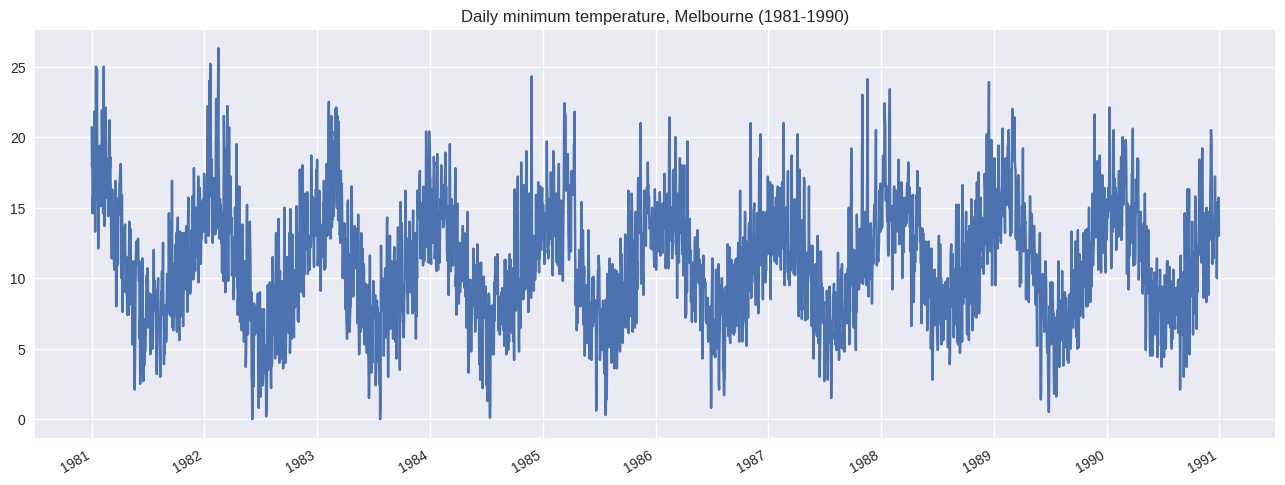

In [9]:
# load the dataset: daily minimum temperatures in Melbourne, 1981-1990
df = pd.read_csv(CFG.data_folder + 'daily-min-temperatures.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

df['Temp'].plot(xlabel='', title='Daily minimum temperature, Melbourne (1981-1990)')
plt.show()

We work with a small, classic series: the daily minimum temperature recorded in Melbourne over ten years, about 3,650 observations. It is a good teaching set because it has obvious yearly seasonality and mild noise but no trend, so the model has something real to learn without us drowning in preprocessing.

`pd.read_csv` reads the file from `CFG.data_folder` into a DataFrame. The `Date` column arrives as plain text, so **`pd.to_datetime`** parses those strings into genuine timestamp objects — without this, pandas could not sort or slice by time. `set_index('Date', inplace=True)` then promotes that column to the DataFrame's index; `inplace=True` modifies `df` directly rather than returning a copy, which is the idiom for "do this to the object I already have."

The standing rule of the series is that a plot of the raw data always comes before any modeling, so we immediately call `.plot()` on the temperature column. Passing `xlabel=''` suppresses the redundant "Date" axis label. The result is a clean sawtooth: ten near-identical yearly cycles, summer peaks and winter troughs, exactly the structure a recurrent net should be able to pick up from a 30-day window.

In [10]:
df.head(3)

,Temp
Date,
1981-01-01,20.7
1981-01-02,17.9
1981-01-03,18.8


A quick `df.head(3)` is the standard sanity check after any data preparation. It confirms three things at once: the index is now a `DatetimeIndex` (the dates run down the left), there is a single `Temp` column of floating-point values, and the units look like plausible Celsius readings rather than something garbled by a parsing slip. Leaving a bare expression as the last line of a cell is how a notebook displays a value — no `print` needed.

In [11]:
scaler = MinMaxScaler()
series = scaler.fit_transform(df[['Temp']])
series[:3]

array([[0.78707224],
       [0.68060837],
       [0.7148289 ]])

Neural networks are sensitive to the scale of their inputs — large raw values push activation functions into flat regions and make the gradients that drive learning behave badly. So we rescale the temperatures into the interval $[0, 1]$ with **`MinMaxScaler`**.

`scaler.fit_transform(df[['Temp']])` does two things in one call: `fit` learns the minimum and maximum of the temperature column, and `transform` maps every value linearly onto $[0, 1]$ using them. We pass `df[['Temp']]` with double brackets so scikit-learn receives a two-dimensional DataFrame (a column), which is the shape it expects, rather than a one-dimensional Series.

Holding on to the `scaler` object is essential, not optional. The network learns and predicts in this squashed $[0,1]$ space, so every prediction it emits must later be pushed back through `scaler.inverse_transform` to recover real degrees before we can score it. Keep the scaler; you will need it in every evaluation cell below. The `series[:3]` preview confirms the values now sit between 0 and 1.

In [12]:
X, y = create_dataset(series, look_back=CFG.LOOK_BACK, look_ahead=CFG.LOOK_AHEAD)
print(X.shape, y.shape)

(3620, 30) (3620, 1)


Here the windowing helper turns the flat scaled series into supervised examples. With `look_back=30` and `look_ahead=1`, each row of `X` is a 30-day history and the matching row of `y` is the single next day. The printed shapes confirm the bookkeeping: `X` is `[samples, 30]` and `y` is `[samples, 1]`, where *samples* is the series length minus the window machinery. Note that `X` is still two-dimensional at this point — the third dimension that RNN layers need gets added in the very next step, inside the split.

In [13]:
X_train, y_train, X_valid, y_valid = prepare_split(
    X, y, cutoff=CFG.CUTOFF, timesteps=CFG.LOOK_BACK
)
print(X_train.shape, X_valid.shape, y_train.shape, y_valid.shape)

(3000, 30, 1) (620, 30, 1) (3000, 1) (620, 1)


`prepare_split` carves off the first `CFG.CUTOFF = 3000` windows as training data and keeps the rest — roughly the final two years — for validation, then reshapes both input blocks into the three-dimensional `[batch, time steps, features]` form. The printed shapes tell the whole story: the training inputs are `(3000, 30, 1)` — three thousand windows, thirty time steps each, one feature per step — and the validation block is the chronological tail. Because the split is by time, the validation set is genuinely the model's future, which is the only honest way to judge a forecaster.

# RNN

With the data shaped correctly we climb the first rung: a single recurrent layer predicting one day ahead. We build the architecture by hand rather than reaching for an automated wrapper (`darts`, `Kats`, or AutoML tooling exist and are what you would use in production), because writing the layers out is what teaches you what each parameter does.

## Single-layer RNN

In [14]:
def build_rnn():
    model = Sequential([
        Input(shape=(None, 1)),
        SimpleRNN(CFG.UNITS),
        Dense(CFG.LOOK_AHEAD),
    ])
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

rnn = build_rnn()

This is the smallest network that does the job, wrapped in a builder function so we can reconstruct a fresh, untrained copy whenever we need one.

**`Sequential`** takes a list of layers and wires them in order, each feeding the next. The first entry, **`Input(shape=(None, 1))`**, declares the shape of one example: the `None` is the time dimension left deliberately unspecified so the model accepts windows of any length, and the `1` is the single feature per step. Next, **`SimpleRNN(CFG.UNITS)`** is the recurrent layer itself — `CFG.UNITS = 24` hidden units, meaning the cell carries a 24-dimensional memory vector from step to step. By default a `SimpleRNN` returns only its *final* hidden state after consuming the whole window, which is exactly what we want when feeding a single prediction head. Finally **`Dense(CFG.LOOK_AHEAD)`** is an ordinary fully-connected layer that maps those 24 numbers down to the one value we are forecasting.

`model.compile` finalises the model for training. `loss='mean_squared_error'` is the quantity minimised — appropriate for a regression target — and `optimizer='adam'` selects Adam, the adaptive gradient method that is the sensible default for almost every recurrent net. Calling `build_rnn()` returns a compiled but still untrained model, ready to inspect.

In [15]:
rnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 24)             │           624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649 (2.54 KB)

 Trainable params: 649 (2.54 KB)

 Non-trainable params: 0 (0.00 B)

`model.summary()` prints the architecture as a table — every layer, its output shape, and its trainable parameter count — and reading it is a good habit before committing to a long training run.

The `SimpleRNN` row carries the bulk of the parameters, and the count is worth understanding because it explains where recurrent nets get expensive. With one input feature and 24 units, the cell holds three sets of weights: input-to-hidden ($1 \times 24$), the recurrent hidden-to-hidden matrix ($24 \times 24$), and a bias per unit ($24$). That recurrent square matrix is the signature of an RNN — every unit feeds back into every unit at the next step — and it is what grows quadratically as you widen the layer. The `Dense` row adds its own handful of weights mapping 24 units to a single output. The total is small here, which is why this model trains in seconds.

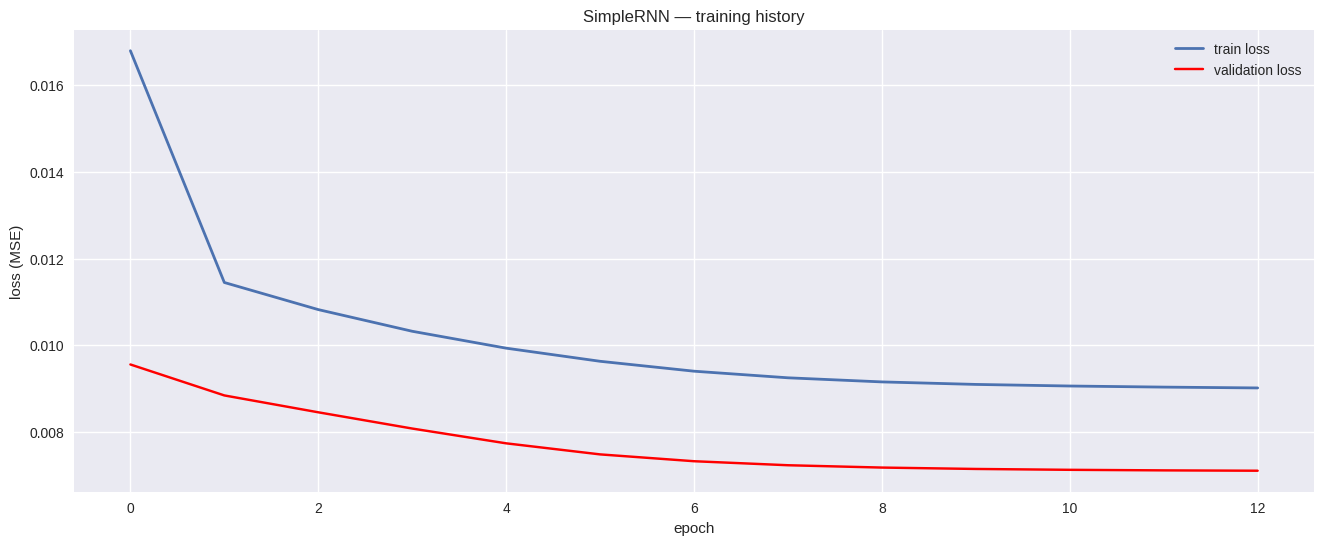

In [16]:
history = rnn.fit(
    X_train, y_train, validation_data=(X_valid, y_valid),
    epochs=CFG.EPOCHS, batch_size=CFG.BATCH_SIZE,
    callbacks=get_callbacks(), verbose=0,
)
plot_history(history, title='SimpleRNN — training history')

`model.fit` runs the training loop and returns a `history` object recording the loss at every epoch.

The arguments: `X_train, y_train` are the inputs and targets; `validation_data=(X_valid, y_valid)` is the held-out future the model is scored against after each epoch but never trains on; `epochs=CFG.EPOCHS` caps the number of passes at 20; `batch_size=CFG.BATCH_SIZE` processes 32 windows before each weight update, trading a little noise for speed; and `callbacks=get_callbacks()` plugs in our early-stopping rule, which may end training before 20 epochs if the validation loss flattens. `verbose=0` keeps the per-epoch log out of the output.

The `plot_history` call is the diagnostic. Read it the way described earlier: we want the red validation curve to descend alongside the training curve and level off, with no late upward turn that would signal overfitting. A clean, jointly-flattening pair of curves means the model has learned what it can from a 30-day window and early stopping has rewound it to its best point.

In [17]:
results = {}
true = scaler.inverse_transform(y_valid)
pred = scaler.inverse_transform(rnn.predict(X_valid, verbose=0))
results['SimpleRNN'] = forecast_metrics(true, pred)
results['SimpleRNN']

{'MAE': 1.7468, 'RMSE': 2.2279}

Now we score the model on the validation set and stash the result. `rnn.predict(X_valid)` produces predictions in the squashed $[0,1]$ space the network lives in, so both the predictions and the true targets are pushed back through `scaler.inverse_transform` to recover real degrees Celsius — without that step the error numbers would be meaningless fractions.

We initialise a `results` dictionary that will accumulate every model's scores as we go, then call `forecast_metrics` and file the answer under `'SimpleRNN'`. The displayed MAE and RMSE are in degrees: a value around a degree or so means the one-day-ahead forecast is typically off by roughly that much, which for a noisy daily temperature is already respectable from such a small network.

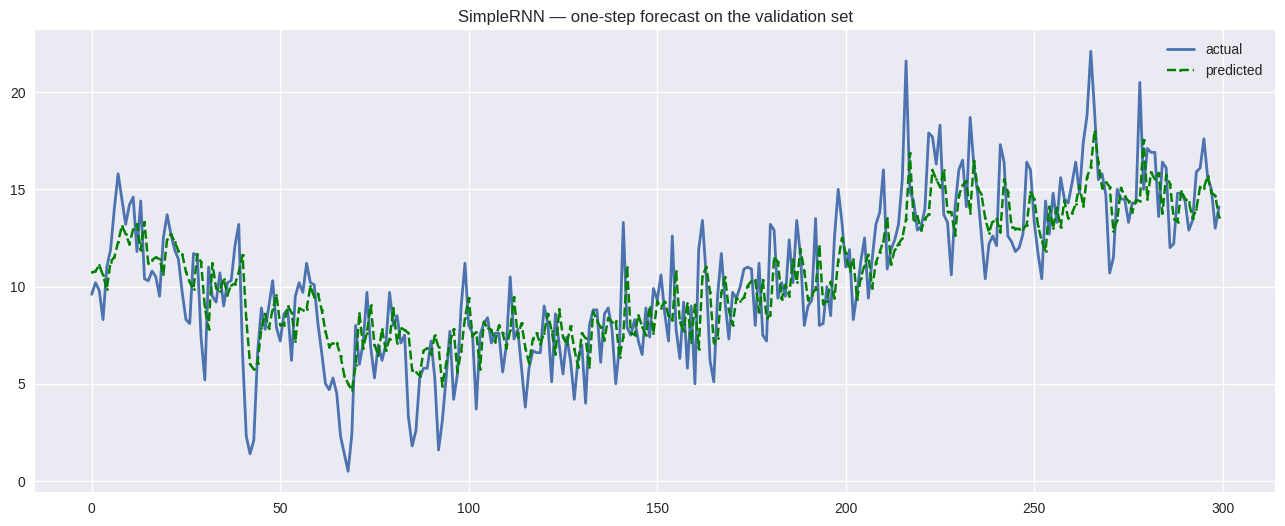

In [18]:
plot_forecast(true, pred, title='SimpleRNN — one-step forecast on the validation set')

The overlay is the visual confirmation of the RMSE. The solid line is the actual validation temperature and the green dashed line the model's one-day-ahead forecast over the first stretch of the held-out period. A single-step forecaster has an easy job in one specific sense — yesterday is a strong clue to today — so we expect the prediction to hug the actual line closely, tracking the seasonal swing and most of the day-to-day wiggle. Where it visibly lags or smooths over a sharp spike is where the 30-day memory is averaging rather than anticipating. This tight tracking is the baseline every later model is trying to beat.

## Stacked RNN

If one recurrent layer learns a decent representation, a natural next move is to stack a second on top so the network can build a more abstract summary of the sequence. Doing so surfaces the single most common error people hit when assembling recurrent architectures, so it is worth meeting deliberately.

In [19]:
def build_stacked_rnn():
    model = Sequential([
        Input(shape=(None, 1)),
        SimpleRNN(CFG.UNITS, return_sequences=True),   # <- must return the full sequence
        SimpleRNN(CFG.UNITS),
        Dense(CFG.LOOK_AHEAD),
    ])
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

stacked = build_stacked_rnn()
stacked.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, None, 24)       │           624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ (None, 24)             │         1,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            25 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,825 (7.13 KB)

 Trainable params: 1,825 (7.13 KB)

 Non-trainable params: 0 (0.00 B)

The new ingredient is **`return_sequences=True`** on the first layer, and it is the gotcha. By default a recurrent layer emits only its final hidden state — a single vector summarising the whole window. But the *second* recurrent layer needs a full sequence to chew on, one hidden state per time step, not a lone vector. If you stack two `SimpleRNN` layers and forget this flag, Keras raises

`ValueError: Input 0 ... incompatible with the layer: expected ndim=3, found ndim=2`

because the second layer was handed a 2-D vector where it wanted a 3-D sequence. Setting `return_sequences=True` on the first layer makes it output the hidden state at *every* step, giving the second layer the sequence it expects. The final recurrent layer keeps the default (no flag), collapsing back to a single vector for the `Dense` head. The summary now shows two recurrent rows; the parameter count roughly doubles in the recurrent part.

In [20]:
history = stacked.fit(
    X_train, y_train, validation_data=(X_valid, y_valid),
    epochs=CFG.EPOCHS, batch_size=CFG.BATCH_SIZE,
    callbacks=get_callbacks(), verbose=0,
)
pred = scaler.inverse_transform(stacked.predict(X_valid, verbose=0))
results['Stacked RNN'] = forecast_metrics(true, pred)
results['Stacked RNN']

{'MAE': 1.7831, 'RMSE': 2.2692}

The fit-and-score block is identical to the single-layer version — same call, same scaler round-trip, same `forecast_metrics` — so it stands without further annotation; only the model object changed. We file the score under `'Stacked RNN'`. Whether the extra depth actually helps on this small, fairly simple series is an empirical question: sometimes a second layer buys a little accuracy, sometimes it merely adds parameters and a touch of variance. The leaderboard at the end will show which happened here.

## Multi-step ahead

So far we have predicted a single day. The reason people reach for recurrent nets, though, is sequence output — forecasting a whole stretch of the future at once. We now rebuild the data to predict ten days ahead (a *many-to-many* setup) and watch what that longer horizon does to a plain RNN.

In [21]:
HORIZON = 10

Xm, ym = create_dataset(series, look_back=CFG.LOOK_BACK, look_ahead=HORIZON)
Xm_train, ym_train, Xm_valid, ym_valid = prepare_split(
    Xm, ym, cutoff=CFG.CUTOFF, timesteps=CFG.LOOK_BACK
)
print(Xm_train.shape, ym_train.shape)

(3000, 30, 1) (3000, 10)


Only one thing changes versus the benchmark task: `look_ahead` jumps from 1 to `HORIZON = 10`. We define it as a named constant just above its first use rather than dropping a bare `10` into the call. `create_dataset` now pairs each 30-day window with the *ten* days that follow it, so the printed target shape is `(3000, 10)` — ten values to predict per example instead of one. The input side is unchanged. Everything downstream simply has to produce ten numbers where it used to produce one.

In [22]:
def build_multistep_rnn(out_dim):
    model = Sequential([
        Input(shape=(None, 1)),
        SimpleRNN(CFG.UNITS, return_sequences=True),
        SimpleRNN(CFG.UNITS),
        Dense(out_dim),
    ])
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

multistep = build_multistep_rnn(out_dim=HORIZON)
history = multistep.fit(
    Xm_train, ym_train, validation_data=(Xm_valid, ym_valid),
    epochs=CFG.EPOCHS, batch_size=CFG.BATCH_SIZE,
    callbacks=get_callbacks(), verbose=0,
)

The architecture is the stacked RNN again with one edit: the output layer is now **`Dense(out_dim)`** with `out_dim=HORIZON`, so the head emits ten numbers — the ten-day forecast — in a single shot. Parameterising the builder by `out_dim` keeps the horizon out of the hardcoded body. Training runs exactly as before.

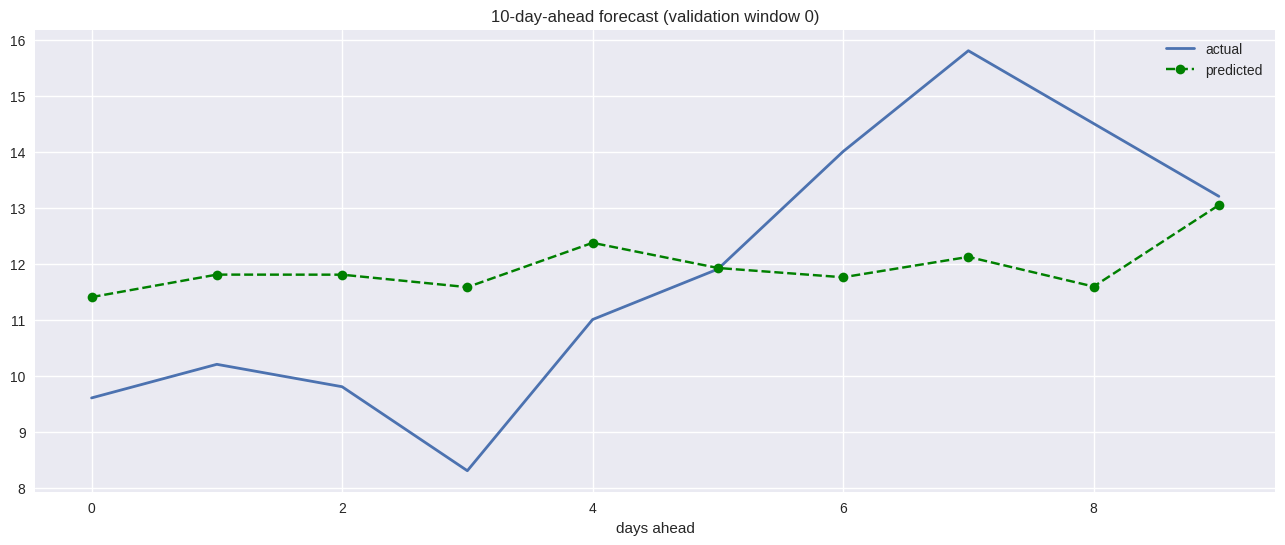

In [23]:
sample = 0
true_path = scaler.inverse_transform(ym_valid[sample].reshape(-1, 1))
pred_path = scaler.inverse_transform(
    multistep.predict(Xm_valid[sample:sample+1], verbose=0).reshape(-1, 1)
)

plt.plot(true_path, label='actual', linewidth=2)
plt.plot(pred_path, label='predicted', color='green', linestyle='--', marker='o')
plt.title(f'10-day-ahead forecast (validation window {sample})')
plt.xlabel('days ahead'); plt.legend(); plt.show()

Plotting a whole-series overlay no longer makes sense — each example is now its own ten-day trajectory — so we pick one validation window and draw its forecast against what actually happened. We take `sample = 0`, inverse-transform both the true ten-day path and the model's prediction back to degrees, and overlay them with the same colour convention as before.

Read the shape of the error across the horizon. The first predicted day or two usually sits close to the truth, then the green path tends to drift — flattening toward the series mean, losing the crispness of the early steps. That widening gap as we look further ahead is not a coincidence; it is the symptom that motivates the rest of the notebook.

### The vanishing-gradient problem

A plain RNN degrades as the horizon grows, and the cause is baked into how BPTT works. Training multiplies gradients back through every unrolled time step. When those per-step factors are smaller than one, the product shrinks **exponentially** as it travels back through time, so the gradient reaching the earliest steps is effectively zero — the network never learns to connect distant past inputs to the current output, it simply "forgets" the start of the window. (The mirror-image failure, factors larger than one, makes gradients *explode* instead.)

The practical consequence is exactly what the plot above hinted at: a `SimpleRNN` can carry information across a handful of steps but struggles to hold a signal across many, so longer-range structure slips away. Curing this is the entire reason the next two architectures exist. Both keep the RNN workflow untouched and rebuild only the inside of the cell, adding *gates* that let useful information flow across many steps without being crushed.

# GRU

The first cure is the **Gated Recurrent Unit**. The outer workflow is unchanged — same sliding windows, same training loop — but inside, the cell now carries two **gates** that regulate its memory.

The **update gate** decides how much of the previous hidden state to carry forward versus how much of a freshly-computed candidate state to write in; when it stays near one, information is copied across many steps almost untouched, which is precisely the long-range pathway a `SimpleRNN` lacks. The **reset gate** decides how much of the past to ignore when forming that candidate, letting the unit drop information that has become irrelevant. Because the network can *learn* to hold a signal open across many steps instead of having it multiplied away, GRUs sidestep the vanishing-gradient trap that hobbled the plain RNN. We swap `SimpleRNN` for `GRU` and change nothing else.

In [24]:
def build_gru():
    model = Sequential([
        Input(shape=(None, 1)),
        GRU(CFG.UNITS, return_sequences=True),
        GRU(CFG.UNITS),
        Dense(CFG.LOOK_AHEAD),
    ])
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

gru = build_gru()

history = gru.fit(
    X_train, y_train, validation_data=(X_valid, y_valid),
    epochs=CFG.EPOCHS, batch_size=CFG.BATCH_SIZE,
    callbacks=get_callbacks(), verbose=0,
)
pred = scaler.inverse_transform(gru.predict(X_valid, verbose=0))
results['GRU'] = forecast_metrics(true, pred)
results['GRU']

{'MAE': 1.7447, 'RMSE': 2.2309}

The cell is a near-verbatim copy of the stacked-RNN block with `SimpleRNN` replaced by **`GRU`** — the same `return_sequences=True` on the lower layer, the same one-step benchmark task, the same scaler round-trip — which is exactly the point: keeping everything else fixed lets us attribute any change in the score purely to the cell type. The gates do cost more parameters per unit (a GRU holds roughly three times the weights of a plain RNN of the same width), so it is a slightly heavier model for the same 24 units. We file the result under `'GRU'` for the final comparison.

# LSTM

The second, older, and most famous cure is the **Long Short-Term Memory** unit. It attacks the same vanishing-gradient problem as the GRU but with more machinery: alongside the hidden state it maintains a separate **cell state**, a memory conveyor that runs the length of the sequence and is edited only through carefully controlled gates.

An LSTM has three gates where the GRU had two. The **forget gate** decides what to erase from the cell state. The **input gate** decides what new information to write into it. The **output gate** decides how much of the cell state to expose as the hidden state passed onward. The intuition is two parallel tracks: a long-term memory (the cell state) that information can ride across many steps almost unchanged, and a short-term working memory (the hidden state) that mixes in the latest input. The separate, gently-edited cell state is what lets gradients survive the trip back through time. You can think of the GRU as a streamlined LSTM that folds these roles into fewer gates; in practice the two often perform comparably, with the LSTM carrying a few more parameters. Again we change only the layer type.

In [25]:
def build_lstm():
    model = Sequential([
        Input(shape=(None, 1)),
        LSTM(CFG.UNITS, return_sequences=True),
        LSTM(CFG.UNITS),
        Dense(CFG.LOOK_AHEAD),
    ])
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

lstm = build_lstm()

history = lstm.fit(
    X_train, y_train, validation_data=(X_valid, y_valid),
    epochs=CFG.EPOCHS, batch_size=CFG.BATCH_SIZE,
    callbacks=get_callbacks(), verbose=0,
)
pred = scaler.inverse_transform(lstm.predict(X_valid, verbose=0))
results['LSTM'] = forecast_metrics(true, pred)
results['LSTM']

{'MAE': 1.749, 'RMSE': 2.2457}

Identical scaffolding once more, with **`LSTM`** in place of `GRU`. The extra gate makes an LSTM the heaviest of the three cells per unit (about four times a plain RNN's weights), which is the price of its explicit cell-state memory. On a series with only mild long-range dependence like daily temperature, LSTM, GRU and even the plain RNN may land close together — the dramatic gap shows up on harder sequences with genuinely long memory. We record the score under `'LSTM'` and move to the fully general setup.

# Going all in: covariates and a bidirectional LSTM

Everything so far has been univariate: one input feature, the temperature itself. Two ingredients remain to make the setup fully general — **multivariate input** (more than one feature per time step) and a **bidirectional** reading of the sequence. We add both in one application section.

The honest, fully-reproducible way to demonstrate multivariate input on a single series is to *engineer covariates* from it: lagged values, rolling averages, and calendar encodings that hand the network extra context at each step. This is also a genuinely useful technique in its own right, so it doubles as a worked example of feature engineering for a recurrent forecaster.

In [26]:
feat = df.copy()

# lagged values: yesterday and a week ago
feat['lag_1'] = feat['Temp'].shift(1)
feat['lag_7'] = feat['Temp'].shift(7)

# rolling averages of the recent past (shifted so they never peek at 'today')
feat['roll_mean_7']  = feat['Temp'].shift(1).rolling(7).mean()
feat['roll_mean_30'] = feat['Temp'].shift(1).rolling(30).mean()

# calendar seasonality encoded as a smooth cycle
doy = feat.index.dayofyear
feat['doy_sin'] = np.sin(2 * np.pi * doy / 365.25)
feat['doy_cos'] = np.cos(2 * np.pi * doy / 365.25)

feat = feat.dropna()
feat.head(3)

,Temp,lag_1,lag_7,roll_mean_7,roll_mean_30,doy_sin,doy_cos
Date,,,,,,,
1981-01-31,15.4,15.1,16.0,16.914286,17.790000,0.508356,0.861147
1981-02-01,15.3,15.4,16.5,16.828571,17.613333,0.523094,0.852275
1981-02-02,18.8,15.3,18.7,16.657143,17.526667,0.537677,0.843151


We start from a `.copy()` of the raw frame so the original `df` is left untouched, then build six covariates.

The **lags** — `shift(1)` and `shift(7)` — bring yesterday's and last-week's temperature alongside today's, giving the network explicit recent anchors. The **rolling means** smooth the recent past into a 7-day and 30-day average; note the `shift(1)` *before* `.rolling(...)`, which is the critical gotcha: it lags the window by a day so that the average for a given date is computed only from days strictly before it. Skip that shift and the feature would include the very value we are trying to predict — a leak that would flatter the model in training and collapse in production.

The **calendar features** encode the day-of-year as a sine/cosine pair. A raw day-number from 1 to 365 has an artificial discontinuity (December 31 sits far from January 1 numerically but is one day away in reality); projecting it onto a sine and cosine of the annual cycle makes the seasonality smooth and continuous, so the network sees late December and early January as neighbours.

Finally `dropna()` discards the first thirty-odd rows where the lags and rolling windows are still incomplete — recurrent layers, like the ADF tests in earlier notebooks, cannot ingest NaNs. The `head(3)` preview shows the seven columns lined up and ready.

In [27]:
target_col = 'Temp'
feature_cols = ['Temp', 'lag_1', 'lag_7', 'roll_mean_7', 'roll_mean_30', 'doy_sin', 'doy_cos']

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
Xmat = scaler_X.fit_transform(feat[feature_cols])
yvec = scaler_y.fit_transform(feat[[target_col]])

def create_multivariate(Xmat, yvec, look_back, look_ahead=1):
    X, y = [], []
    for i in range(len(Xmat) - look_back - look_ahead + 1):
        X.append(Xmat[i : i + look_back, :])                       # all features
        y.append(yvec[i + look_back : i + look_back + look_ahead, 0])
    return np.array(X), np.array(y).reshape(-1, look_ahead)

Xv, yv = create_multivariate(Xmat, yvec, CFG.LOOK_BACK, CFG.LOOK_AHEAD)
print(Xv.shape, yv.shape)

(3590, 30, 7) (3590, 1)


The multivariate path needs two scalers, not one. `scaler_X` rescales the full feature matrix (all seven columns at once) and a separate `scaler_y` rescales the target on its own — keeping the target's scaler separate is what lets us cleanly invert just the predictions later, since the features and the target no longer share a single transform.

`create_multivariate` is the windowing helper adapted for more than one feature. The only change from `create_dataset` is the input slice: `Xmat[i : i + look_back, :]`, where the trailing `:` keeps *all* feature columns instead of selecting column 0. So each input window is now a little matrix — 30 time steps by 7 features — and the target stays a single future temperature drawn from the target column. The printed shape confirms it: `Xv` is `[samples, 30, 7]`, exactly the three-dimensional tensor a recurrent layer wants, now with a real feature dimension rather than a placeholder 1.

In [28]:
cut = 3000
Xv_train, Xv_valid = Xv[:cut], Xv[cut:]
yv_train, yv_valid = yv[:cut], yv[cut:]
print(Xv_train.shape, Xv_valid.shape)

(3000, 30, 7) (590, 30, 7)


The split is chronological exactly as before — first 3000 windows to train, the rest to validate — and because the windows are already in `[batch, steps, features]` shape, no reshape is needed this time. The same reasoning applies: the validation block is the model's future, so the score it earns is an honest estimate of forecasting performance.

In [29]:
n_features = Xv.shape[-1]

def build_bilstm(n_features, look_back):
    model = Sequential([
        Input(shape=(look_back, n_features)),
        Bidirectional(LSTM(64, return_sequences=True)),
        Bidirectional(LSTM(32)),
        Dense(16, activation='relu'),
        Dense(CFG.LOOK_AHEAD),
    ])
    model.compile(loss='mean_squared_error', optimizer='adam')
    return model

bilstm = build_bilstm(n_features, CFG.LOOK_BACK)
bilstm.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 30, 128)        │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,137 (309.13 KB)

 Trainable params: 79,137 (309.13 KB)

 Non-trainable params: 0 (0.00 B)

The final architecture introduces the **`Bidirectional`** wrapper. It is exactly that — a wrapper you place around any recurrent layer — and it runs two copies of that layer over the window, one reading front-to-back and one reading back-to-front, then concatenates their outputs. The forward pass sees the past leading up to each step; the backward pass sees the rest of the window. Within a fixed input window (as opposed to a live streaming forecast) the model is allowed to use the whole window's context, and reading it both ways often sharpens the representation.

A few other details differ from the univariate builders, since this is a harder problem. The `Input` layer now fixes a concrete shape, `(look_back, n_features)` = `(30, 7)`, because the feature count is real and known. We stack two bidirectional LSTM layers (64 then 32 units) with `return_sequences=True` on the first so the second receives a full sequence, exactly the stacking rule from earlier. A small `Dense(16, activation='relu')` adds a non-linear head before the final `Dense` output. The summary shows the parameter count climb well above the toy models above — the bidirectional wrapping alone doubles each recurrent layer's weights.

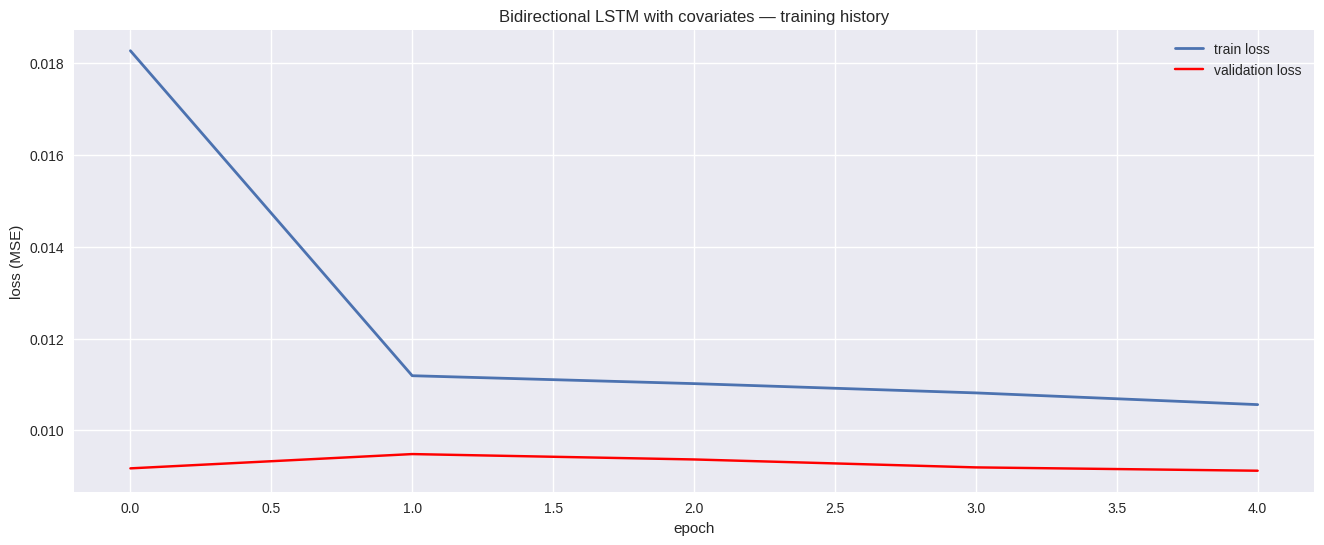

In [30]:
history = bilstm.fit(
    Xv_train, yv_train, validation_data=(Xv_valid, yv_valid),
    epochs=CFG.EPOCHS, batch_size=CFG.BATCH_SIZE,
    callbacks=get_callbacks(), verbose=0,
)
plot_history(history, title='Bidirectional LSTM with covariates — training history')

Training uses the identical loop as every model before it; only the data and the model object are richer. The history plot is again the diagnostic — with a larger model and more features there is more capacity to overfit, so this is the moment to check that the red validation curve stays down with the training curve rather than peeling upward. Early stopping is the safety net if it does.

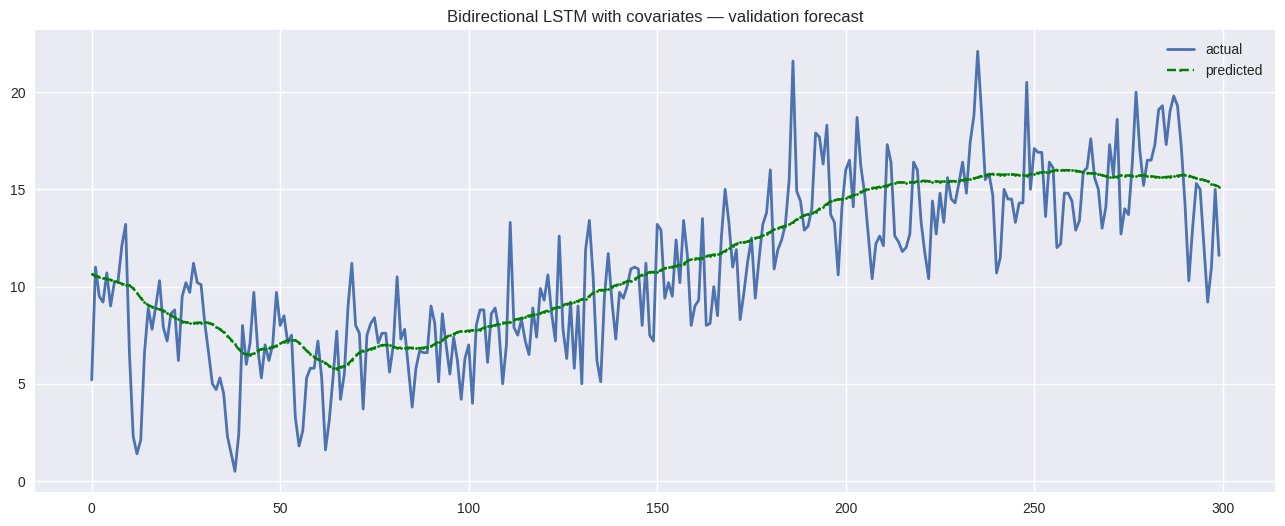

In [31]:
pred_bi = scaler_y.inverse_transform(bilstm.predict(Xv_valid, verbose=0))
true_bi = scaler_y.inverse_transform(yv_valid)
results['BiLSTM + covariates'] = forecast_metrics(true_bi, pred_bi)

plot_forecast(true_bi, pred_bi, title='Bidirectional LSTM with covariates — validation forecast')

Scoring follows the now-familiar pattern, with one change to watch: we invert through `scaler_y`, the target-only scaler, rather than the univariate `scaler` from the top of the notebook. The lagged and calendar covariates give this model strictly more information than the univariate networks had, so we might *expect* a tighter fit — though as the leaderboard below shows, expecting and getting are not the same thing. One honest caveat first: because this branch uses its own scaler and a slightly shorter series (the rows dropped by `dropna`), its score is indicative rather than a perfectly controlled head-to-head — close, but not to the last decimal.

In [32]:
comparison = pd.DataFrame(results).T.sort_values('RMSE')
comparison

,MAE,RMSE
SimpleRNN,1.7468,2.2279
GRU,1.7447,2.2309
LSTM,1.7490,2.2457
Stacked RNN,1.7831,2.2692
BiLSTM + covariates,1.9440,2.5184


The closing table assembles every model's scores into one tidy frame and sorts by RMSE, best at the top. Building `pd.DataFrame(results)` from the accumulated dictionary and transposing with `.T` puts one model per row and the two metrics in columns.

Read it as a story rather than a verdict on one run — neural-network training is stochastic, and on a short, mild series the gaps between architectures are small. Two things stand out here. First, the plain `SimpleRNN`, the `GRU` and the `LSTM` land almost on top of one another: on a one-step forecast of a gently seasonal series, yesterday is already most of the signal, so the gating machinery that rescues long-range memory has little to bite on. Second — and more instructive — the big bidirectional model with seven engineered covariates does **not** come out ahead; it sits at the bottom. More parameters and more features are not free wins. A larger model needs either a harder problem (genuinely long-range dependence) or a longer training budget to justify its capacity, and on this easy task it mostly added variance. That anticlimax is the real lesson of the leaderboard: match the architecture to the structure the problem actually contains, rather than reaching for the heaviest tool by default.

# Where this hands off

We climbed the full ladder: a single `SimpleRNN` predicting one step, then depth, then a longer horizon that exposed the **vanishing-gradient** problem, then **GRU** and **LSTM** gating as the two cures, and finally a **bidirectional** network drinking in engineered **covariates**. That is the complete recurrent toolkit for sequences.

These architectures share one structural weakness, though, and it is worth naming because it sets up what comes next. An encoder-decoder RNN has to squeeze the *entire* input sequence into a single fixed-size hidden state — an **information bottleneck**. For short windows like ours that is fine, but as sequences grow long, forcing all of the past through one vector starts to lose detail no amount of gating fully recovers.

The fix is **attention**: instead of compressing everything into one state, let the model look back at *all* of the encoder's hidden states and weigh them by relevance for each output step. That idea, taken to its logical extreme, removes the recurrence entirely and gives the **transformer** — but that is the subject of the next notebook. Consider this the teaser trailer.